In [11]:
import os
import json
import matplotlib.pyplot as plt
from matplotlib import font_manager
font_path = "/usr/share/fonts/truetype/msttcorefonts/Arial.ttf"
font_manager.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "Arial"


238.88096000000002


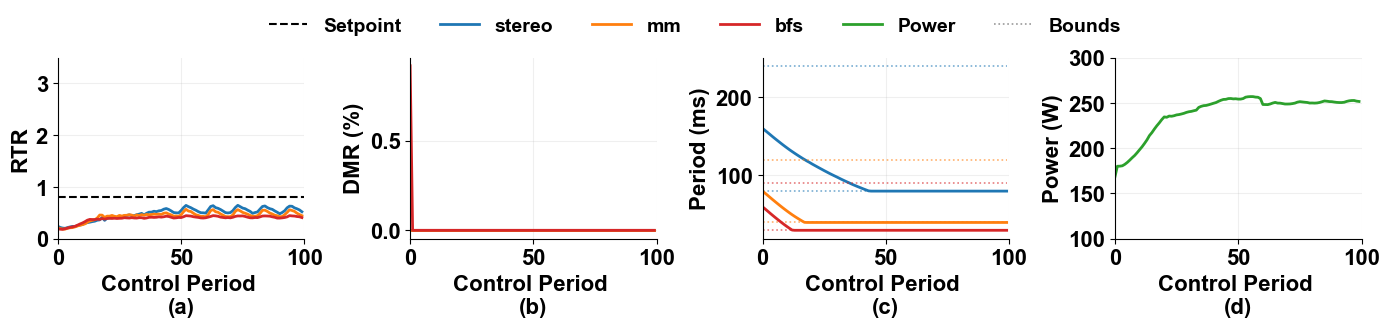

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

# --------- CONFIG ----------
root = Path("FC-GPU_bounds/quasirand_converted_mm_converted_bfs_converted") 
root = Path("FC-GPU_bounds/stereodisparity_converted_mm_converted_bfs_converted") 
setpoints = [0.80]
warmup_skip = 0         
max_periods = 100      
save_path = Path("figures")
task_names = ["stereo", "mm", "bfs"]
task_colors = ['tab:blue', 'tab:orange', 'tab:red']

# Styling constants
FIGSIZE = (14, 3.5) 
TICK_FONTSIZE = 16
LINEWIDTH = 2.0
LABEL_FONTSIZE=16
# ---------------------------

def read_data(filepath: Path):
    if not filepath.exists(): return None
    vals = []
    with filepath.open("r") as f:
        for line in f:
            s = line.strip()
            if not s: continue
            try: vals.append(float(s))
            except ValueError: continue
    return vals if vals else None

def slice_idx(data, start, stop):
    if data is None: return None
    n = len(data)
    a = min(max(start, 0), n)
    b = min(max(stop, 0), n)
    return np.asarray(data[a:b], dtype=float)

plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial']})

for sp in setpoints:
    run_dir = root / f"setpoint_{sp:.2f}_{sp:.2f}_{sp:.2f}"
    
    data = {name: {} for name in task_names}
    for i, name in enumerate(task_names, 1):
        t_id = f"t{i}"
        data[name]['rtr'] = slice_idx(read_data(run_dir / f"FC_GPU_{t_id}_rtr.txt"), warmup_skip, max_periods)
        data[name]['dl']  = slice_idx(read_data(run_dir / f"FC_GPU_{t_id}_deadline.txt"), warmup_skip, max_periods)
        data[name]['per'] = slice_idx(read_data(run_dir / f"FC_GPU_{t_id}_period.txt"), warmup_skip, max_periods)
        data[name]['low'] = slice_idx(read_data(run_dir / f"FC_GPU_{t_id}_lowerperiodbound.txt"), warmup_skip, max_periods)
        data[name]['high']= slice_idx(read_data(run_dir / f"FC_GPU_{t_id}_higherperiodbound.txt"), warmup_skip, max_periods)

    pwrs = slice_idx(read_data(run_dir / "FC_GPU_finalpowervalues.txt"), warmup_skip, max_periods)

    fig, axs = plt.subplots(1, 4, figsize=FIGSIZE)

    # (1) RTR
    ax = axs[0]
    ax.axhline(y=sp, color='black', linestyle='--', linewidth=1.5, label="Setpoint")
    for name, color in zip(task_names, task_colors):
        if data[name]['rtr'] is not None:
            ax.plot(data[name]['rtr'], linewidth=LINEWIDTH, label=name, color=color)
    ax.set_ylabel("RTR", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period \n(a)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_ylim(0, 3.5)

    # (2) Deadline
    ax = axs[1]
    for name, color in zip(task_names, task_colors):
        if data[name]['dl'] is not None:
            ax.plot(data[name]['dl'], linewidth=LINEWIDTH, color=color)
    ax.set_ylabel("DMR (%)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period \n(b)", fontsize=LABEL_FONTSIZE, fontweight='bold')

    # (3) Period
    ax = axs[2]
    for name, color in zip(task_names, task_colors):
        if data[name]['per'] is not None:
            ax.plot(data[name]['per'], linewidth=LINEWIDTH, color=color)
        if data[name]['low'] is not None:
            ax.plot(data[name]['low'], ':', alpha=0.6, linewidth=1.2, color=color)
        if data[name]['high'] is not None:
            ax.plot(data[name]['high'], ':', alpha=0.6, linewidth=1.2, color=color)
    ax.set_ylabel("Period (ms)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period \n(c)", fontsize=LABEL_FONTSIZE, fontweight='bold')

    # (4) Power
    ax = axs[3]
    if pwrs is not None:
        ax.plot(pwrs, linewidth=LINEWIDTH, color='tab:green', label='Power')
    ax.set_ylabel("Power (W)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period \n(d)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_ylim([100,300])
    print(np.mean(pwrs))

    # Global Styling
    for ax in axs:
        ax.set_xlim([0,100])
        ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
        for tick in ax.get_xticklabels(): tick.set_fontweight("bold")
        for tick in ax.get_yticklabels(): tick.set_fontweight("bold")
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, alpha=0.2)

    # --- NO-OVERLAP LEGEND ---
    # Create the handles manually to ensure they include bounds
    handles, labels = axs[0].get_legend_handles_labels() # Tasks + Setpoint
    # Add Power handle
    power_handle = Line2D([0], [0], color='tab:green', linewidth=LINEWIDTH)
    handles.append(power_handle)
    labels.append("Power")
    bound_handle = Line2D([0], [0], color='gray', linestyle=':', linewidth=1.2, alpha=0.8)
    handles.append(bound_handle)
    labels.append("Bounds")
    #fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.93),           ncol=len(labels), frameon=True, fontsize=16, prop={'weight':'bold'})
    fig.legend(
        handles, 
        labels, 
        loc='upper center', 
        bbox_to_anchor=(0.5, 0.95),  
        ncol=len(labels), 
        frameon=False, 
        # Move size inside prop to avoid it being overridden
        prop={'weight': 'bold', 'size': 14} 
    )   

    
    plt.tight_layout(rect=[0, 0, 1, 0.85]) 
    
    save_path.mkdir(exist_ok=True)
    plt.savefig(save_path / 'inner_motivation_1.pdf', bbox_inches='tight')
    plt.show()

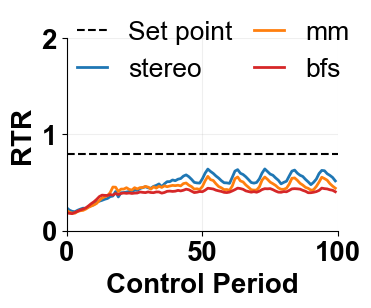

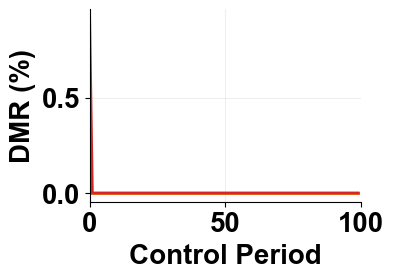

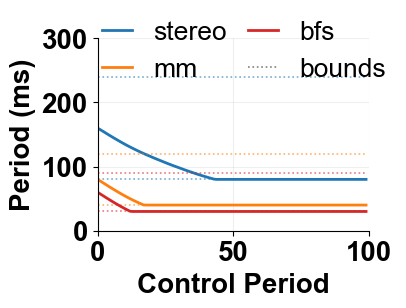

Mean Power: 238.88W


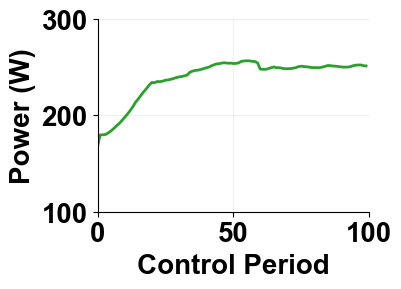

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

# --------- CONFIG ----------
# Note: Using the second root definition from your snippet
root = Path("FC-GPU_bounds/stereodisparity_converted_mm_converted_bfs_converted") 
setpoints = [0.80]
warmup_skip = 0         
max_periods = 100      
save_path = Path("figures")
task_names = ["stereo", "mm", "bfs"]
task_colors = ['tab:blue', 'tab:orange', 'tab:red']

# Styling constants
FIGSIZE = (3.5, 2.5) # Adjusted for single plot aspect ratio
TICK_FONTSIZE = 20
LINEWIDTH = 2
LABEL_FONTSIZE = 20
# ---------------------------

def read_data(filepath: Path):
    if not filepath.exists(): return None
    vals = []
    with filepath.open("r") as f:
        for line in f:
            s = line.strip()
            if not s: continue
            try: vals.append(float(s))
            except ValueError: continue
    return vals if vals else None

def slice_idx(data, start, stop):
    if data is None: return None
    n = len(data)
    a = min(max(start, 0), n)
    b = min(max(stop, 0), n)
    return np.asarray(data[a:b], dtype=float)

def apply_styling(ax, ylabel, xlabel):
    ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlim([0, 100])
    ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
    for tick in ax.get_xticklabels(): tick.set_fontweight("bold")
    for tick in ax.get_yticklabels(): tick.set_fontweight("bold")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.2)

plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial']})
save_path.mkdir(exist_ok=True)

for sp in setpoints:
    run_dir = root / f"setpoint_{sp:.2f}_{sp:.2f}_{sp:.2f}"
    
    # Pre-load data
    data = {name: {} for name in task_names}
    for i, name in enumerate(task_names, 1):
        t_id = f"t{i}"
        data[name]['rtr'] = slice_idx(read_data(run_dir / f"FC_GPU_{t_id}_rtr.txt"), warmup_skip, max_periods)
        data[name]['dl']  = slice_idx(read_data(run_dir / f"FC_GPU_{t_id}_deadline.txt"), warmup_skip, max_periods)
        data[name]['per'] = slice_idx(read_data(run_dir / f"FC_GPU_{t_id}_period.txt"), warmup_skip, max_periods)
        data[name]['low'] = slice_idx(read_data(run_dir / f"FC_GPU_{t_id}_lowerperiodbound.txt"), warmup_skip, max_periods)
        data[name]['high']= slice_idx(read_data(run_dir / f"FC_GPU_{t_id}_higherperiodbound.txt"), warmup_skip, max_periods)
    
    pwrs = slice_idx(read_data(run_dir / "FC_GPU_finalpowervalues.txt"), warmup_skip, max_periods)

    # --- FIGURE 1: RTR ---
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.axhline(y=sp, color='black', linestyle='--', linewidth=1.5, label="Set point")
    for name, color in zip(task_names, task_colors):
        if data[name]['rtr'] is not None:
            ax.plot(data[name]['rtr'], linewidth=LINEWIDTH, label=name, color=color)
    apply_styling(ax, "RTR", "Control Period")
    ax.set_ylim(0, 2)
    #ax.legend(frameon=False, ncols=2, prop={'weight':'bold', 'size': 14})
    #ax.legend(frameon=False, prop={'weight': 'bold', 'size': 16}, ncol=2, loc='lower center', bbox_to_anchor=(0.5, 0.95))
    ax.legend(
        frameon=False,          
        fancybox=False,        
        framealpha=0.4,        
        shadow=False,  
        fontsize=19,
        loc='upper center',
        # 0.5 centers it; 1.25 keeps it just above the plot
        bbox_to_anchor=(0.54, 1.15), 
        ncol=2,
        columnspacing=0.8,
        handlelength=1.15,
        borderaxespad=0. 
    )

    plt.savefig(save_path / 'fig_FC_GPU_rtr.pdf', bbox_inches='tight')
    plt.show()

    # --- FIGURE 2: Deadline (DMR) ---
    fig, ax = plt.subplots(figsize=FIGSIZE)
    for name, color in zip(task_names, task_colors):
        if data[name]['dl'] is not None:
            ax.plot(data[name]['dl'], linewidth=LINEWIDTH, color=color, label=name)
    apply_styling(ax, "DMR (%)", "Control Period")
    plt.savefig(save_path / 'fig_FC_GPU_dmr.pdf', bbox_inches='tight')
    plt.show()

    # --- FIGURE 3: Period ---
    fig, ax = plt.subplots(figsize=FIGSIZE)
    for name, color in zip(task_names, task_colors):
        if data[name]['per'] is not None:
            # Added label=name here so the legend knows what to call the line
            ax.plot(data[name]['per'], linewidth=LINEWIDTH, color=color, label=name)
        if data[name]['low'] is not None:
            ax.plot(data[name]['low'], ':', alpha=0.6, linewidth=1.2, color=color)
        if data[name]['high'] is not None:
            ax.plot(data[name]['high'], ':', alpha=0.6, linewidth=1.2, color=color)

    # 1. Get the handles and labels that were automatically created (the Tasks)
    handles, labels = ax.get_legend_handles_labels()

    # 2. Create the custom handle for the dotted lines
    bound_handle = Line2D([0], [0], color='gray', linestyle=':', linewidth=1.2)
    handles.append(bound_handle)
    labels.append("bounds")

    # 4. Pass the combined lists into the legend
    # ax.legend(
    #     handles=handles, 
    #     labels=labels, 
    #     frameon=False, 
    #     fontsize=16,
    #     ncol=2, 
    #     loc='lower center', 
    #     bbox_to_anchor=(0.5, 0.95)
    # )
    #ax.legend(frameon=False, prop={'weight': 'bold', 'size': 16}, ncol=2, loc='lower center', bbox_to_anchor=(0.5, 0.95))
    ax.legend(
        handles=handles, 
        labels=labels, 
        frameon=False,          
        fancybox=False,        
        framealpha=0.4,        
        shadow=False,  
        fontsize=19,
        loc='upper center',
        # 0.5 centers it; 1.25 keeps it just above the plot
        bbox_to_anchor=(0.54, 1.15), 
        ncol=2,
        columnspacing=0.8,
        handlelength=1.15,
        borderaxespad=0. 
    )

    ax.set_ylim([0, 300])
    apply_styling(ax, "Period (ms)", "Control Period")
    plt.savefig(save_path / 'fig_FC_GPUperiod.pdf', bbox_inches='tight')
    plt.show()

    # --- FIGURE 4: Power ---
    fig, ax = plt.subplots(figsize=FIGSIZE)
    if pwrs is not None:
        ax.plot(pwrs, linewidth=LINEWIDTH, color='tab:green')
        print(f"Mean Power: {np.mean(pwrs):.2f}W")
    apply_styling(ax, "Power (W)", "Control Period")
    ax.set_ylim([100, 300])
    plt.savefig(save_path / 'fig_FC_GPUpower.pdf', bbox_inches='tight')
    plt.show()

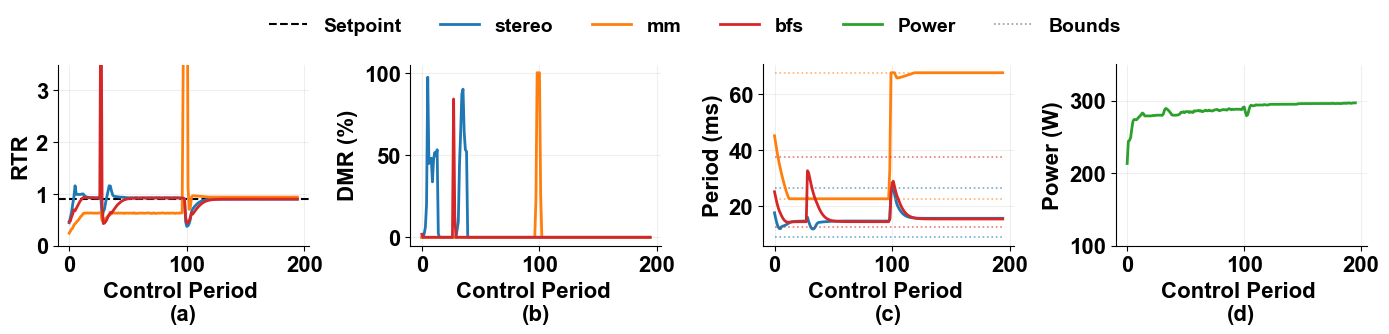

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

# --------- CONFIG ----------
root = Path("FC-GPU_bounds1/quasirand_converted_mm_interrupt_bfs_converted") 
setpoints = [0.90]
warmup_skip = 0         
max_periods = 200        
save_path = Path("figures")
task_names = ["stereo", "mm", "bfs"]
task_colors = ['tab:blue', 'tab:orange', 'tab:red']

# Styling constants
FIGSIZE = (14, 3.5) # Slightly taller/wider to prevent overlap
LABEL_FONTSIZE = 16
TICK_FONTSIZE = 16
LINEWIDTH = 2.0
# ---------------------------

def read_data(filepath: Path):
    if not filepath.exists(): return None
    vals = []
    with filepath.open("r") as f:
        for line in f:
            s = line.strip()
            if not s: continue
            try: vals.append(float(s))
            except ValueError: continue
    return vals if vals else None

def slice_idx(data, start, stop):
    if data is None: return None
    n = len(data)
    a = min(max(start, 0), n)
    b = min(max(stop, 0), n)
    return np.asarray(data[a:b], dtype=float)

plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial']})

for sp in setpoints:
    run_dir = root / f"setpoint_{sp:.2f}_{sp:.2f}_{sp:.2f}"
    
    data = {name: {} for name in task_names}
    for i, name in enumerate(task_names, 1):
        t_id = f"t{i}"
        data[name]['rtr'] = slice_idx(read_data(run_dir / f"FC_GPU_{t_id}_rtr.txt"), warmup_skip, max_periods)
        data[name]['dl']  = slice_idx(read_data(run_dir / f"FC_GPU_{t_id}_deadline.txt"), warmup_skip, max_periods)
        data[name]['per'] = slice_idx(read_data(run_dir / f"FC_GPU_{t_id}_period.txt"), warmup_skip, max_periods)
        data[name]['low'] = slice_idx(read_data(run_dir / f"FC_GPU_{t_id}_lowerperiodbound.txt"), warmup_skip, max_periods)
        data[name]['high']= slice_idx(read_data(run_dir / f"FC_GPU_{t_id}_higherperiodbound.txt"), warmup_skip, max_periods)

    pwrs = slice_idx(read_data(run_dir / "FC_GPU_finalpowervalues.txt"), warmup_skip, max_periods)

    fig, axs = plt.subplots(1, 4, figsize=FIGSIZE)

    # (1) RTR
    ax = axs[0]
    ax.axhline(y=sp, color='black', linestyle='--', linewidth=1.5, label="Setpoint")
    for name, color in zip(task_names, task_colors):
        if data[name]['rtr'] is not None:
            ax.plot(data[name]['rtr'], linewidth=LINEWIDTH, label=name, color=color)
    ax.set_ylabel("RTR", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period \n(a)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_ylim(0, 3.5)

    # (2) Deadline
    ax = axs[1]
    for name, color in zip(task_names, task_colors):
        if data[name]['dl'] is not None:
            ax.plot(data[name]['dl'], linewidth=LINEWIDTH, color=color)
    ax.set_ylabel("DMR (%)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period \n(b)", fontsize=LABEL_FONTSIZE, fontweight='bold')

    # (3) Period
    ax = axs[2]
    for name, color in zip(task_names, task_colors):
        if data[name]['per'] is not None:
            ax.plot(data[name]['per'], linewidth=LINEWIDTH, color=color)
        if data[name]['low'] is not None:
            ax.plot(data[name]['low'], ':', alpha=0.6, linewidth=1.2, color=color)
        if data[name]['high'] is not None:
            ax.plot(data[name]['high'], ':', alpha=0.6, linewidth=1.2, color=color)
    ax.set_ylabel("Period (ms)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period \n(c)", fontsize=LABEL_FONTSIZE, fontweight='bold')

    # (4) Power
    ax = axs[3]
    if pwrs is not None:
        ax.plot(pwrs, linewidth=LINEWIDTH, color='tab:green', label='Power')
    ax.set_ylabel("Power (W)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period \n(d)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_ylim([100,350])

    # Global Styling
    for ax in axs:
        ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
        for tick in ax.get_xticklabels(): tick.set_fontweight("bold")
        for tick in ax.get_yticklabels(): tick.set_fontweight("bold")
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, alpha=0.2)
        #ax.set_xlim([0,100])


    # --- NO-OVERLAP LEGEND ---
    # Create the handles manually to ensure they include bounds
    handles, labels = axs[0].get_legend_handles_labels() # Tasks + Setpoint
    # Add Power handle
    power_handle = Line2D([0], [0], color='tab:green', linewidth=LINEWIDTH)
    handles.append(power_handle)
    labels.append("Power")
    bound_handle = Line2D([0], [0], color='gray', linestyle=':', linewidth=1.2, alpha=0.8)
    handles.append(bound_handle)
    labels.append("Bounds")

    # Place legend high above the plots
    #fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98),           ncol=len(labels), frameon=True, fontsize=16, prop={'weight':'bold'})
    
    fig.legend(
        handles, 
        labels, 
        loc='upper center', 
        bbox_to_anchor=(0.5, 0.97),  
        ncol=len(labels), 
        frameon=False, 
        # Move size inside prop to avoid it being overridden
        prop={'weight': 'bold', 'size': 14} 
    )   
    plt.tight_layout(rect=[0, 0, 1, 0.85]) 
    
    save_path.mkdir(exist_ok=True)
    plt.savefig(save_path / 'inner_run1.pdf', bbox_inches='tight')
    plt.show()